In [1]:
import numpy as np

#-------------------------#
import ipympl

%matplotlib ipympl
# %matplotlib widget
#-------------------------#
import matplotlib.pyplot as plt
import mpl_interactions.ipyplot as iplt
#-------------------------#

from matplotlib.patches import Rectangle as plt_rec

In [2]:
def show_rec(rec,**kwargs):
    return plt_rec(
        (rec.center[0]-rec.distances[0],rec.center[1]-rec.distances[1]),   
        rec.distances[0]*2, #height
        rec.distances[1]*2, #width
        **kwargs)

In [3]:
class Cell:
    def __init__(self,center,distances,score=0,scored=False):
        '''
        center: the geometric center (d-dimensional array).
        distances: distance of the center of each axis to the edge of the axis (d-dimensional array).

        If I have the 2d rectange with vertices at {(0,0), (0,2), (1,0), (1,2)}
        the center is (0.5, 1). Alternative way of thinking about it: the two sides parallel to the x-axis have a 
        center at x = 0.5 and the two sides parallel to the y-axis have a center at y = 1. The corresponding
        distances are 0.5 and 1.
        '''
        
        self.center=center[:]
        self.distances=distances[:]
        self.dim=len(center)
        
        self.score=score
        self.scored=scored
        
        self.vertex_points()
        
    def sign(self,i,j):
        r'''
            This generates an alternating pattern of signs that enumerates all 2^d
            possible sign vectors of a d-dimensional rectangle.
            
            Each sign vector tells us how to move from the center of the rectangle to one
            vertex:
            
                vertex = center + sign_vector * distances_d
            
            The same sign vectors can also be used to locate the centers of the
            subrectangles after subdivision:
            
                child_center = center + sign_vector * (distances_d / 2)
            

            My way of thinking:
            If you imagine a circle divided into j equal picies with \delta\theta=\pi/(2^(j-1)), 
            then the sign can be defined as + if \theta = i*\delta\theta <= \pi and - if \theta = i*\delta\theta > \pi.
            
            Alternative way of thinking:
            For each coordinate j, the sign is a 'square wave' as a function of the
            vertex (or child) index i. The last coordinate flips every step, the previous
            one flips every two steps, the previous one every four steps, and so on.
            Equivalently, coordinate j flips every 2^(d-j-1) steps.

            This is the idea this fucntion follows.
        '''
        #shift to call i,j as a list that start from 0 at 0
        i=i+1
        j=j+1
        
        dt=1/2**(j-1)#the step in units of \pi
        t=(i-1)#the steps you take, i=\theta/\delta\theta

        semicircle=np.floor((t*dt)%2)#this checks whether you are in the upper or lower half of the circle
        return int((-1)**semicircle)#this gives you the sign
    


    def split(self,axis):
        '''
        split the cell along the "axis" axis
        axis: the axis to split
        '''            

        new_distances = self.distances[:]
        new_distances[axis] = self.distances[axis] / 2.
        children=[None]*2
    
        for j, sign in enumerate([-1, +1]):
            new_center = self.center[:]
            new_center[axis] = self.center[axis] + sign * new_distances[axis]            
            children[j]=Cell(new_center,new_distances)

        return children



    def axis_to_split(self, score_function):
        '''
        Split all axes, compute score, and return the
        axis that splits the score as unevenly as possible.
        '''
        best_axis = 0
        
        cells = self.split(best_axis)
        score_0 = score_function(cells[0])
        score_1 = score_function(cells[1])
        best_imbalance = abs(score_0 - score_1)
    
        for axis in range(1, self.dim):
            cells = self.split(axis)
    
            score_0 = score_function(cells[0])
            score_1 = score_function(cells[1])
    
            imbalance = abs(score_0 - score_1)
    
            if imbalance > best_imbalance:
                best_imbalance = imbalance
                best_axis = axis
    
        return best_axis

    
    def volume(self):
        '''Return the volume of this rectangle.'''
        v=1
        for dis in self.distances:
            v*=2*dis
        return v

    def vertex_points(self):
        '''generate all vertex points of the rectangle'''
        
        self.vertices=[]
        for bound in range(2**self.dim):
            self.vertices.append([self.center[d]+self.distances[d]*self.sign(bound,d) for d in range(self.dim)])

    
    def check_point(self,point):
        '''check whether point is inside this rectangle'''
        for d in range(self.dim):
            if point[d]>self.center[d]+self.distances[d] or point[d]<self.center[d]-self.distances[d]:
                return False
        return True

    def random_point(self):
        '''generate a random point in this rectangle'''
        
        point=[]
        for d in range(self.dim):
            _M=self.center[d]+self.distances[d]
            _m=self.center[d]-self.distances[d]
            point.append(np.random.rand()*(_M-_m)+_m)
            
        return point

In [4]:
if False:
    c1=Cell([0.5]*2,[0.5]*2)
    c2,c3=c1.split(0)
    
    fig=plt.figure(figsize=(4,4))
    fig.subplots_adjust(bottom=0.1, left=0.1, top = 0.9, right=0.9,wspace=0.0,hspace=0.5)
    
    sub = fig.add_subplot(111)
    
    
    sub.add_patch(show_rec(c1,fill=False,color='xkcd:blue',linewidth=3))
    sub.add_patch(show_rec(c2,fill=False,color='xkcd:red',linestyle='--',linewidth=3))
    sub.add_patch(show_rec(c3,fill=False,color='xkcd:black',linestyle=':',linewidth=3))
    
    
    
    sub.set_xlim(-1,2)
    sub.set_ylim(-1,2)
    plt.show()

In [15]:
class Grid:
    '''
    The DTree class recursively splits the chosen axes.
    '''
    def __init__(self,cell,max_splits=np.inf):
        '''
        cell: instance of Cell. 
        
        max_splits: number of allowed splits
        
        score: This is a number. I will use this to assign values to each rectangle and later decide to split an axis it or not. 
        
        '''
        
        #We deal with rectangles, but use the dim when you can. It will be easier to generalize later.
        self.dim=cell.dim
        
            
        self.cells=[cell]
        
        self.max_splits=max_splits
        self.splits=0


    def split(self,which_cell,axis):
        if self.splits >= self.max_splits:
            return
        
        self.splits+=1
        
        new_cells=self.cells[which_cell].split(axis)
        self.cells.pop(which_cell)
        for _c in new_cells:
            self.cells.append(_c) 
        
    def assign_score(self, score_function):
        '''
        Run score_function in each cell to assign the scores. 
        
        score_function: a function that takes a node (not just a rectangle) and returns a number.
        '''
        if self.splits >= self.max_splits:
            return
        
        for cell in self.cells:
            if not cell.scored:
                cell.score=score_function(cell)
                cell.scored=True


    def conditional_split(self, score_function, condition):
        '''
        Check the score and split if condition returns True.

        score_function: the score function
        condition: a function that takes a value and returns True or False.
        '''
        if self.splits >= self.max_splits:
            return

        n_old = len(self.cells)
    
        for i in range(n_old - 1, -1, -1):
            cell = self.cells[i]
        
            
            if condition(cell.score):
                ### split a random axis
                # axis=np.random.choice(range(self.dim))
                ### split by maximizing the score difference
                axis=cell.axis_to_split(score_function)
                
                self.split(i,axis)


In [33]:
#generate a number of points from a gaussian
# points = np.random.normal([0.5,0],[0.1,0.1],(1500,2))
# points = np.random.uniform(0,0.3,(500,2))


theta = np.pi / 3   
u = np.array([np.cos(theta), np.sin(theta)])
v = np.array([-np.sin(theta), np.cos(theta)])
sigma_parallel = 0.01
sigma_perp = 0.1
cov = sigma_parallel**2 * np.outer(u, u) + sigma_perp**2 * np.outer(v, v)
p1=np.random.multivariate_normal([0.3, 0], cov, size=500)

theta = np.pi / 10  
u = np.array([np.cos(theta), np.sin(theta)])
v = np.array([-np.sin(theta), np.cos(theta)])
sigma_parallel = 0.5
sigma_perp = 0.005
cov = sigma_parallel**2 * np.outer(u, u) + sigma_perp**2 * np.outer(v, v)
p2=np.random.multivariate_normal([0.6, -0.5], cov, size=5000)

points = np.concatenate(
    [   
        p1,p2,
        np.random.normal([-0.4,0.5],[0.1,0.1],(500,2))
    ]
    
    )


In [34]:
#at a node, check the number of points
def number_of_points(cell):
    score=0
    for point in points:
        #avoid branches by adding 1 or 0 depending on true or false
        score+=float(cell.check_point(point))        
    return score

In [37]:
g = Grid( Cell([0,0],[1,1]) , max_splits=2000)

for _ in range(g.max_splits):
    
    g.assign_score( score_function = number_of_points )
    
    g.conditional_split(score_function = number_of_points, condition= lambda score: score>10)

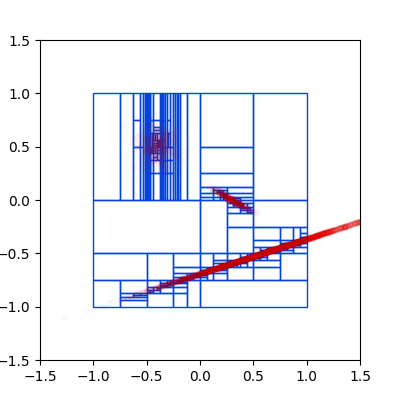

In [38]:
if True:
    
    fig=plt.figure(figsize=(4,4))
    fig.subplots_adjust(bottom=0.1, left=0.1, top = 0.9, right=0.9,wspace=0.0,hspace=0.5)
    
    sub = fig.add_subplot(111)
    
    for _ in g.cells:
        sub.add_patch(show_rec(_,fill=False,color='xkcd:blue',linewidth=1))
    
    sub.scatter(points[:,0],points[:,1],s=10,edgecolor='xkcd:red',facecolors="none",alpha=0.03)

    sub.set_xlim(-1.5,1.5)
    sub.set_ylim(-1.5,1.5)
    plt.show()